
## 자체교정 RAG
- 기본적인 RAG는 사용자의 질문에 대해 관련 문서를 검색하고 이를 기반으로 답변을 생성하는 방식이다. 
- RAG의 답변 결과는 검색된 문서가 사용자 질문과 얼마나 관련이 있는지에 따라 크게 달라진다. 
- 검색된 문서가 질문과 충분한 관련이 없을 경우 생성된 답변의 품질이 크게 저하되는 한계가 존재한다.

In [20]:
import os

from dotenv import load_dotenv

load_dotenv()

GEMMA_MODEL = os.getenv("GEMMA_MODEL")
BASE_URL = os.getenv("BASE_URL")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")
API_KEY = os.getenv("API_KEY")
QDRANT_URL = os.getenv("QDRANT_URL")

In [9]:
from qdrant_client import QdrantClient

qdrant_client = QdrantClient(
    url=QDRANT_URL,
)

In [24]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL,
    base_url=BASE_URL,
    api_key=API_KEY,
    check_embedding_ctx_length=False,)

urls = [
    "https://google.github.io/styleguide/pyguide.html",
    "https://google.github.io/styleguide/javaguide.html",
    "https://google.github.io/styleguide/jsguide.html",
]

docs = [WebBaseLoader(url).load() for url in urls]

docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)

doc_split = text_splitter.split_documents(docs_list)

In [ ]:
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore

vector_size = len(embeddings.embed_query("차원 확인"))
print(vector_size)
qdrant_client.create_collection(
    collection_name="rag_corrective",
    vectors_config=VectorParams(
        size=vector_size,
        distance=Distance.COSINE,
    ),
)

vectorstore = QdrantVectorStore(
    client=qdrant_client,
    collection_name="rag_corrective",
    embedding=embeddings,
)

vectorstore.add_documents(doc_split)

In [22]:
retriever = vectorstore.as_retriever()

In [28]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

def call_model():
    return ChatOpenAI(
        base_url=BASE_URL,
        api_key=API_KEY,
        model=GEMMA_MODEL,
        temperature=0.5,
    )


class GradeDocument(BaseModel):
    binary_score: str = Field(description="문서와 질문의 연관성 여부. (예 or 아니오")

llm = call_model()

structured_llm_grader = llm.with_structured_output(GradeDocument)

system = """당신은 사용자의 질문에 대해 검색된 문서의 관련성을 평가하는 전문가 입니다.
문서에 질문과 관련된 키워드나 의미가 담겨 있으면 해당 문서를 '관련 있음'으로 평가하세요.
문서가 질문과 관련이 있는지 여부를 '예' 또는 '아니오'로 표시해주세요.
"""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "검색된 문서 : \n\n {document} \n\n 사용자 질문 {question}"),
    ]
)

retrieval_grader = grade_prompt|structured_llm_grader

In [30]:
question = "자바 코드 작성 가이드"

docs = retriever.invoke(question)
print(len(docs))

doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

4
binary_score='예'


In [31]:
from langchain_core.output_parsers import StrOutputParser

system = """당신은 질문에 답변하는 업무를 돕는 도우미입니다.
제공된 문맥을 바탕으로 질문에 답변하세요. 만약 답을 모르면 모른다고 말하세요.
세문장을 넘지 않도록 간결하게 작성하세요
"""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "질문 : {question} \n 문맥: {context}\n 답변"),
    ]
)

def format_docs(docs):
    return  "\n\n".join(doc.page_content for doc in docs)

rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke(
    {"context":format_docs(docs),  "question":question})

print(generation)


제공된 문맥은 Google Java Style Guide입니다. 이 가이드는 자바 소스 코드에 대한 Google의 완전한 코딩 표준을 정의합니다.

이 가이드라인은 단순히 미적인 형식뿐만 아니라, 모든 개발자가 따라야 할 관례와 코딩 표준까지 포괄적으로 다룹니다. 여기에 명시된 규칙을 준수하는 것이 'Google Style'로 간주됩니다.


In [32]:
system =  """당신은 입력된 질문을 변형하여 웹 검색에 최적화된 형태로 만드는 질문 생성기입니다.
입력된 질문을 보고 그 이면에 있는 의도나 의미를 파악해주세요."""

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "질문 \n\n {question} \n 더 나은 질문으로 바꿔주세요")
    ]
)

question_rewriter = rewrite_prompt  | llm | StrOutputParser()


In [33]:
question = "C++ 깔끔하게 짜고 싶다."
rewrite_question = question_rewriter.invoke({"question": question})
print(rewrite_question)

입력하신 질문은 **목표**이지, 웹 검색 엔진이 답을 줄 수 있는 구체적인 **질문**은 아닙니다.

"깔끔한 코드(Clean Code)"는 매우 광범위한 개념입니다. C++에서 코드를 깔끔하게 짠다는 것은 단순히 문법적으로 오류가 없는 것을 넘어, **가독성(Readability), 유지보수성(Maintainability), 효율성(Efficiency)** 세 가지를 모두 갖추었다는 의미입니다.

따라서, 검색의 목표가 **'스타일 가이드 찾기'**인지, **'근본적인 설계 원칙 배우기'**인지에 따라 질문을 다르게 만들어야 합니다.

아래는 사용자의 의도(목표)에 따라 검색 효율을 극대화한 5가지 유형의 질문들입니다. 원하는 목표를 선택하여 검색해 보세요.

---

### 🎯 목표별 최적화된 검색 질문 (Search Queries)

#### 🥇 유형 1: [가장 추천] 현대적인 C++ 문법을 익히고 싶다면 (Modernization)
**가장 많은 초보자들이 놓치는 부분은 '구식 C++' 문법을 쓰는 것입니다. 현대적인 C++(C++11 이상) 기능을 사용하면 코드가 압도적으로 깔끔해집니다.**

*   **검색어:** `Modern C++ best practices`
    *(C++11, 14, 17, 20의 새로운 기능을 활용한 모범 사례를 찾습니다.)*
*   **검색어:** `C++ idiomatic usage`
    *(해당 언어 커뮤니티에서 '이것이 올바른 C++스러운 방법이다'라고 인정하는 패턴을 찾습니다.)*
*   **검색어:** `C++ smart pointer vs raw pointer guide`
    *(메모리 관리는 깔끔한 코드의 핵심입니다. 특히 `std::unique_ptr` 등의 사용법을 깊이 있게 찾아봅니다.)*

#### 🥈 유형 2: 코드의 품질과 설계 원칙을 배우고 싶다면 (Design & Architecture)
**코드가 작아지더라도, 그 코드를 둘러싼 구조가 엉망이면 깔끔하다고 할 수 없습니다. 대규모 

In [36]:
from ddgs import DDGS
from typing import List, TypedDict
from langchain_core.documents import Document

class GradeState(TypedDict):
    question: str
    generation: str
    web_search: str
    documents: List[str]

In [39]:
from langchain_community.tools import DuckDuckGoSearchRun

web_search_tool = DuckDuckGoSearchRun()

In [46]:
def retrieve(state):
    """문서를 검색한다.
    Args:
        state (dict): 현재 그래프의 상태
    Return:
        state (dict): 검색된 문서를 포함한 새로운 상태
    """
    print("==검색==")
    question = state["question"]

    documents = retriever.invoke(question)
    return {"documents": documents,  "queston": question}


def generate(state):
    """답변을 생성한다
    Args:
        state (dict): 현재 그래프의 상태
    Return:
        state (dict): LLM이 생성한 답변을 포함한 새로운 상태
    """
    print("==생성==")
    question = state["question"]
    documents = state["documents"]

    generation = rag_chain.invoke({"context":documents, "question":question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """검색된 문서가 질문과 연관이 있는지 평가한다.
    Args:
        state (dict): 현재 그래프의 상태
    Return:
        state (dict): 연관이 있다고 판단한 문서가 업데이트된 상태
    """
    print("==문서와 질문의 연관성 평가==")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    web_search = "아니오"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if  grade ==  "예":
            print("==평가 : 연관 문서==")
            filtered_docs.append(d)
        else:
            print("==평가 : 연관 없는 문서 == ")
            web_search = "예"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    질문을 더 적한한 형태로 변경한다.
    Args:
        state (dict): 현재 그래프의 상태
    Return:
        state (dict): 변환된 질문이 업데이트된 상태
    """
    print("==질문 변환==")
    question = state["question"]
    documents = state["documents"]

    better_question = question_rewriter.invoke({"question" :question})
    return {"documents": documents, "better_question": better_question}


def web_search(state):
    """
    웹 검색을 수행한다.
    Args
        state (dict): 현재 그래프의 상태
    Return:
        state (dict): 웹 검색 결과가 업데이트된 상태
    """
    print("==웹검색==")
    question = state["question"]
    documents = state["documents"]

    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)
    return {"documents": documents, "question": question}


def decide_to_generate(state):
    """
    답변을 생성할지, 질문을 생성할지 결정한다.
    Args:
        state (dict): 현재 그래프의 상태
    Return:
        state (dict): 다음에 호출할 노드
    """
    print("==문서 검토")
    web_search = state["web_search"]

    if web_search == "예":
        print("==연관 문서가 없음==")
        return "transform_query"
    else:
        print("==연관 문서가 있음. 답변 생성")
        return "generate"


In [47]:
from langgraph.graph import END, StateGraph, START


workflow = StateGraph(GradeState)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search_node", web_search)

# 그래프 정의

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)

workflow.add_edge("transform_query",  "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

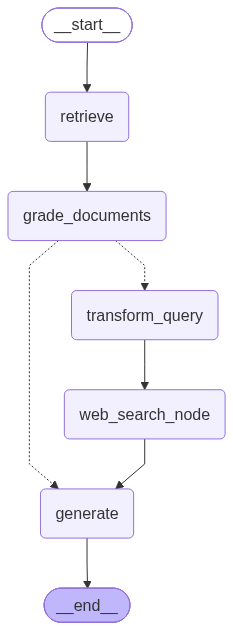

In [43]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [52]:
from pprint import pp

inputs = {"question" : "구글의 코드 작성 가이드"}
for output in app.stream(inputs):
    for key, value in output.items():
        pp(f"Node {key}")

pp(value["generation"])


==검색==
'Node retrieve'
==문서와 질문의 연관성 평가==
==평가 : 연관 문서==
==평가 : 연관 문서==
==평가 : 연관 문서==
==평가 : 연관 문서==
==문서 검토
==연관 문서가 있음. 답변 생성
'Node grade_documents'
==생성==
'Node generate'
('구글은 프로그래밍 언어별로 자체적인 코드 작성 표준 가이드를 제공합니다.\n'
 '\n'
 '제공된 문맥에는 Google JavaScript Style Guide, Google Python Style Guide, 그리고 '
 'Google Java Style Guide가 포함되어 있습니다.\n'
 '\n'
 '각 가이드는 해당 언어의 소스 코드가 갖춰야 할 완전한 코딩 표준과 규칙을 정의하고 있습니다.')
